In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [179]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv') #sobre este conjunto es sobre el que vamos a hacer nuestras predicciones

In [180]:
test_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [34]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [35]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [36]:
col_eliminar = ['Alley','MasVnrType','PoolQC','Fence','MiscFeature']
train_df = train_df.drop(col_eliminar,axis=1)
test_df = test_df.drop(col_eliminar,axis=1)

# Creación del conjunto de entrenamiento y de prueba
## Vamos a buscar correlaciones para estratificar el conjunto de entrenamiento y de prueba a partir de la variable mejor correlacionada con nuestra variable objetivo

Creamos una matriz de correlación para poder ver cuales son las variables más correlacionadas con la columna objetivo, vamos a obtener las 5 variables más correlacionadas positivamente y las otras 5 variables más correlacionadas negativamente.

In [37]:
corr_matriz = train_df.corr(numeric_only=True).sort_values(by='SalePrice',ascending=False)
n= 10
print(f"Estas son las {n} variables más correlacionadas positivamente: {corr_matriz['SalePrice'][:n]}\n")
print(f"Estas son las {n} variables más correlacionadas positivamente: {corr_matriz['SalePrice'][-n:]}\n")

Estas son las 10 variables más correlacionadas positivamente: SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Estas son las 10 variables más correlacionadas positivamente: BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64



Parece que hay más variables que se correlacionan positivamnte con nuestra variable target, así que vamos a imprimir las primeras 20 de corr_matriz para ver hasta que punto hay una correlación decente con la variable objetivo.

In [38]:
corr_matriz['SalePrice'][:25]

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
BsmtUnfSF       0.214479
BedroomAbvGr    0.168213
ScreenPorch     0.111447
Name: SalePrice, dtype: float64

Hay una correlación fuerte hasta YearRemodAdd

Ahora vamos a dividir nuestro conjunto de entrenamiento en un conjunto de entrenamiento y de prueba con train_test_split de sklearn

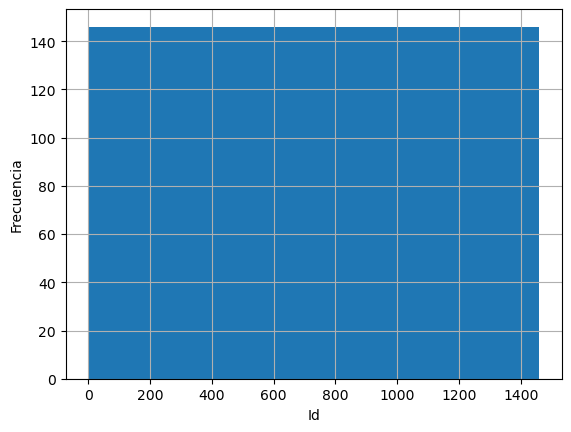

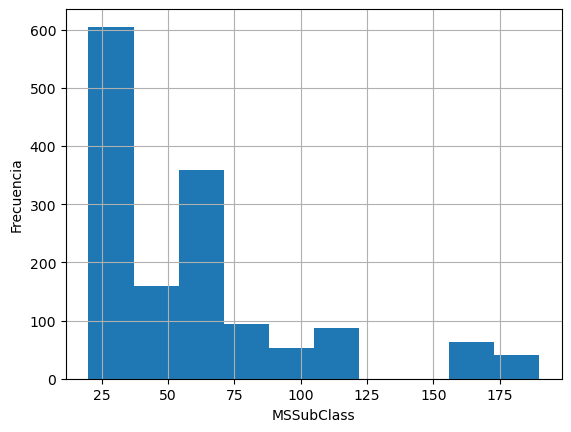

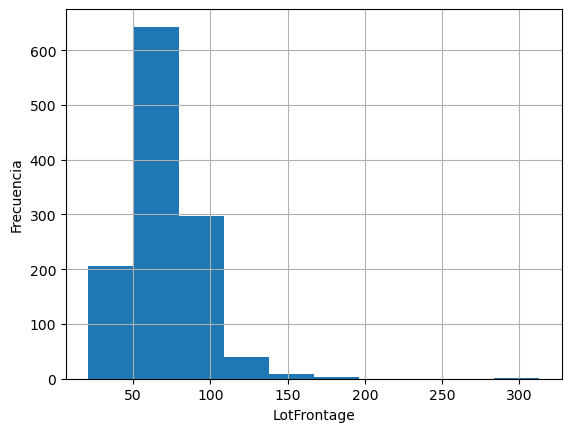

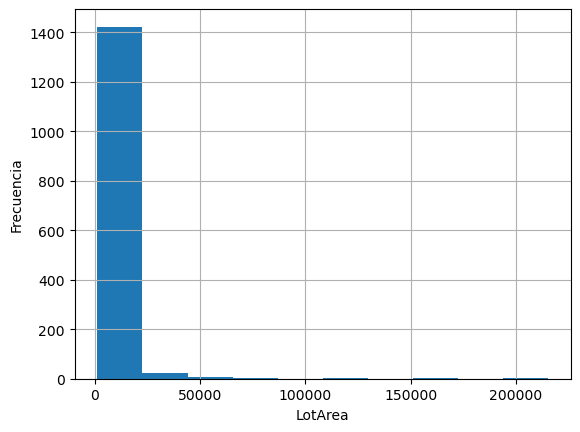

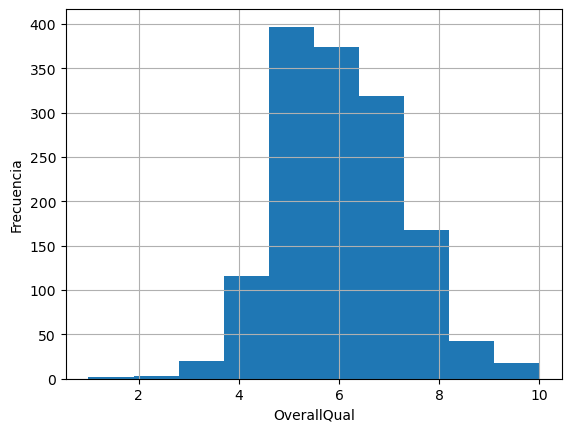

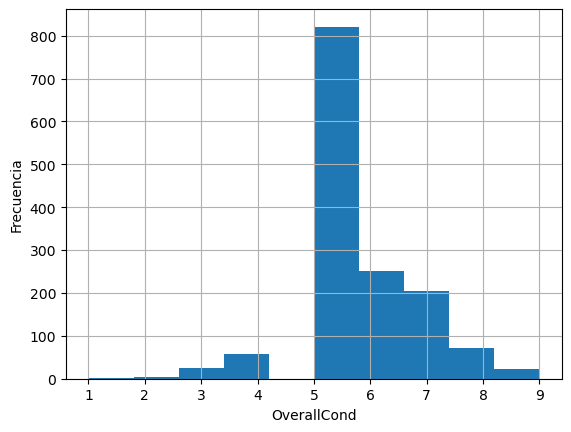

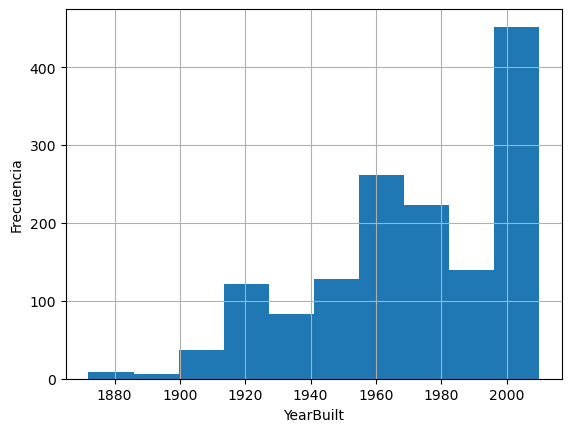

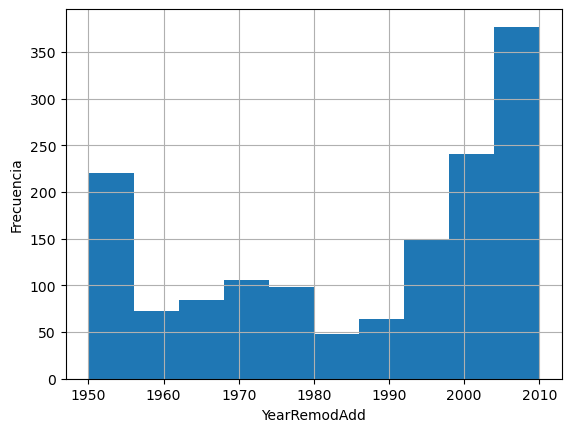

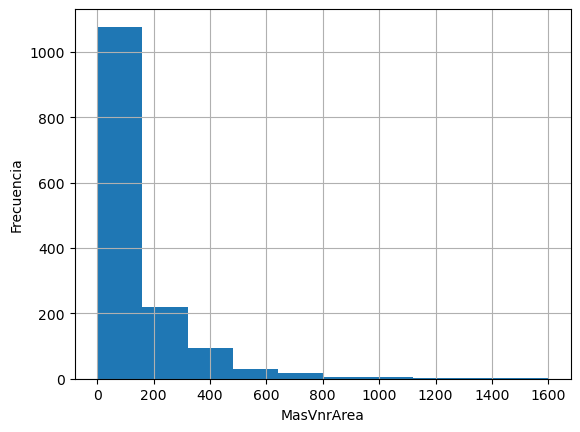

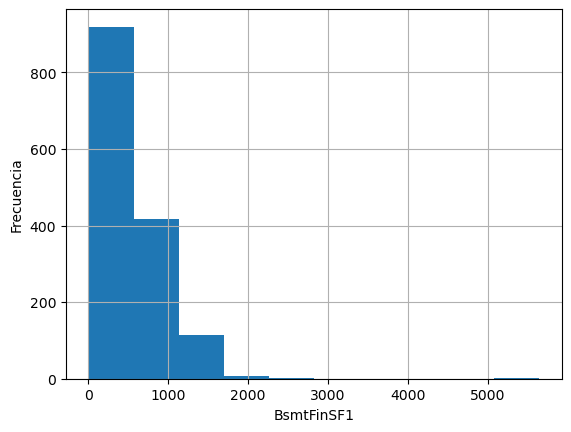

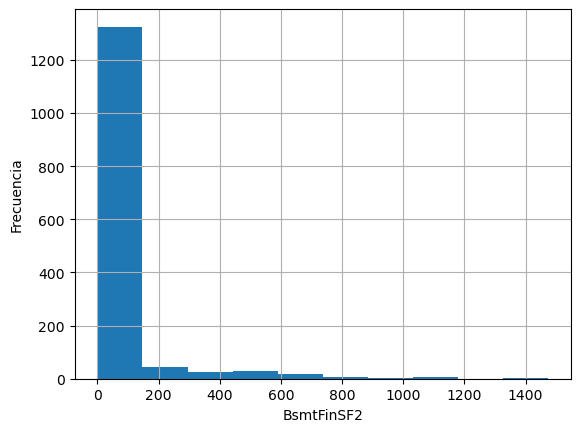

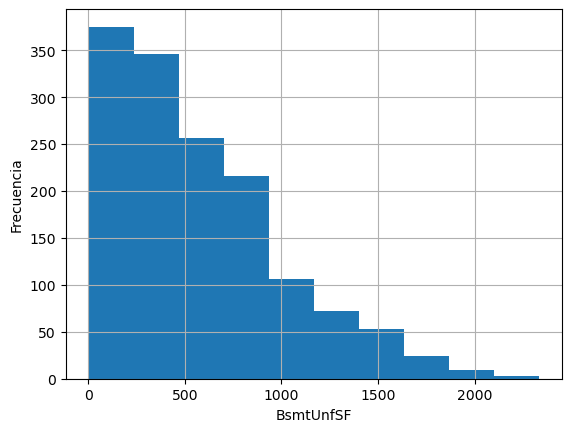

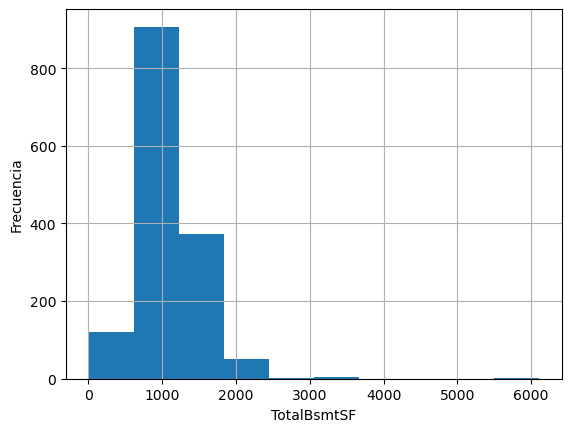

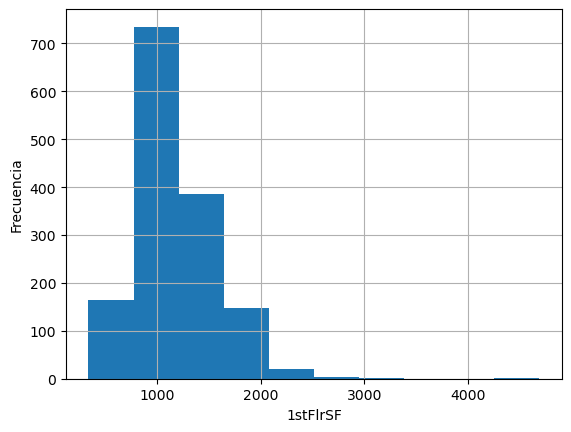

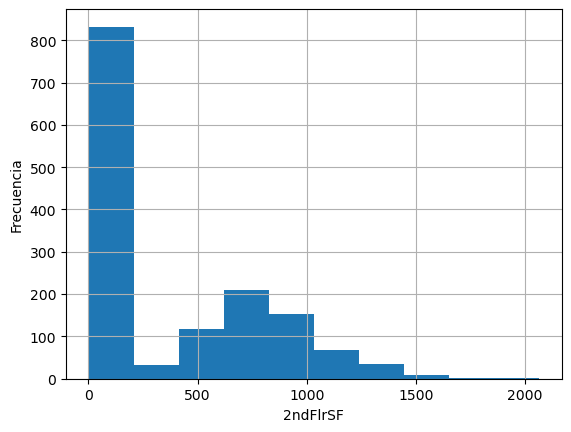

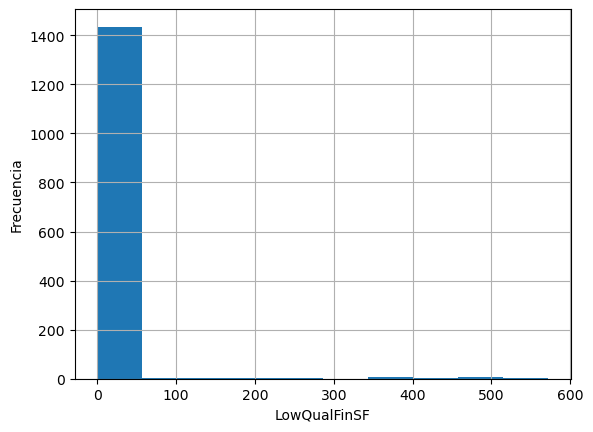

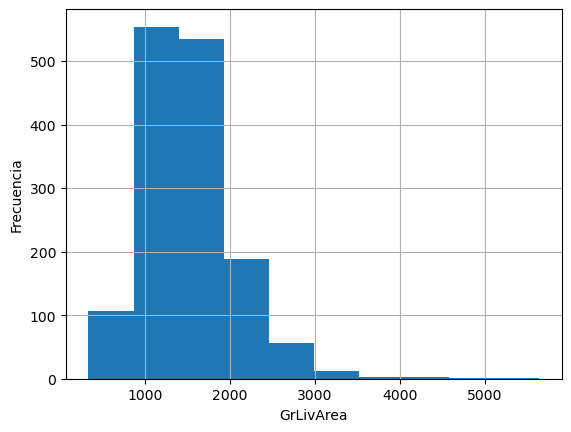

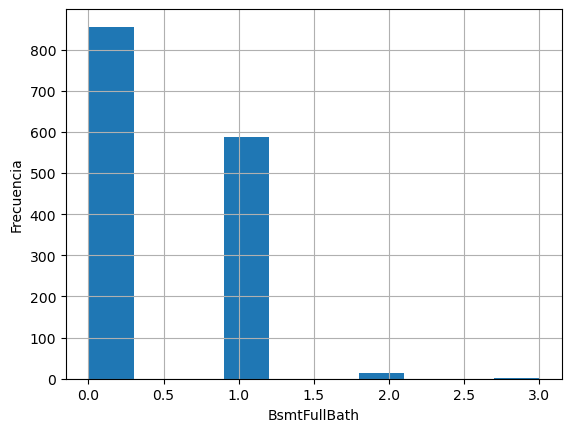

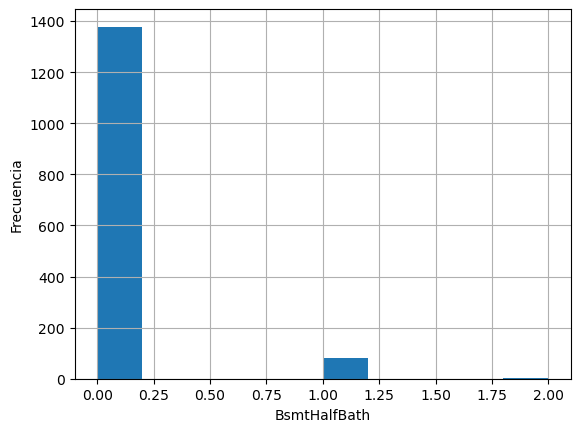

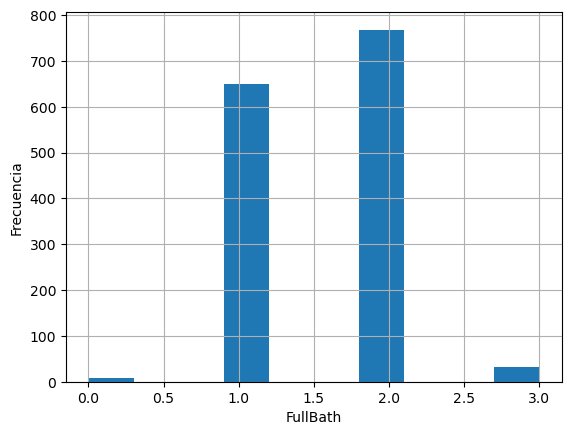

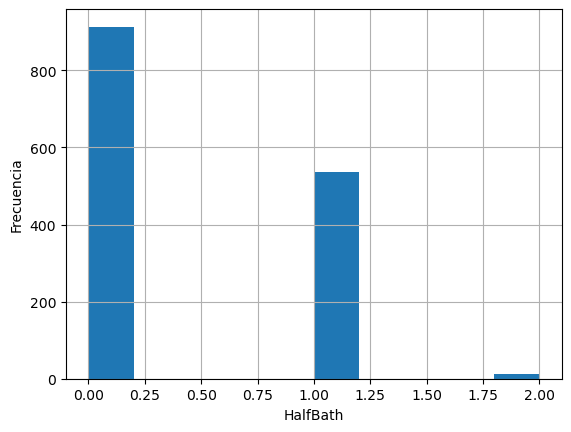

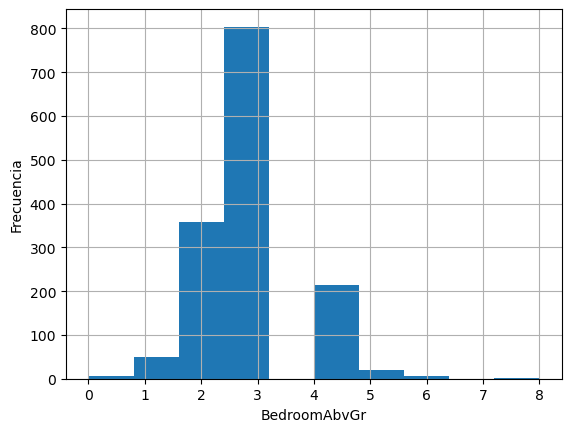

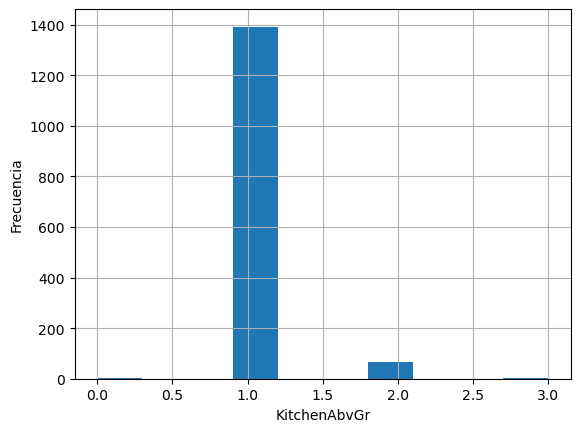

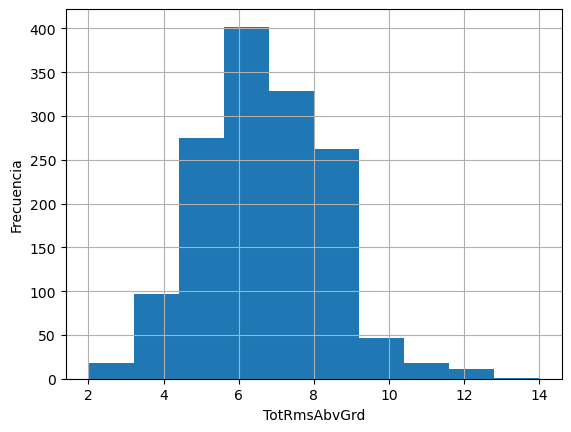

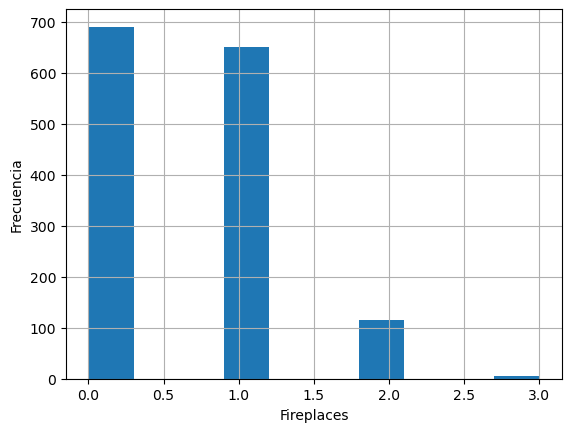

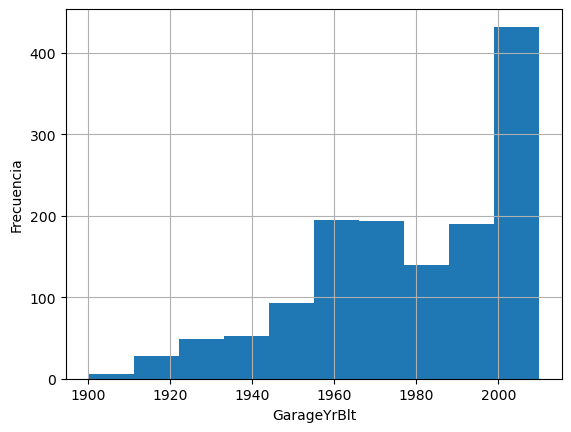

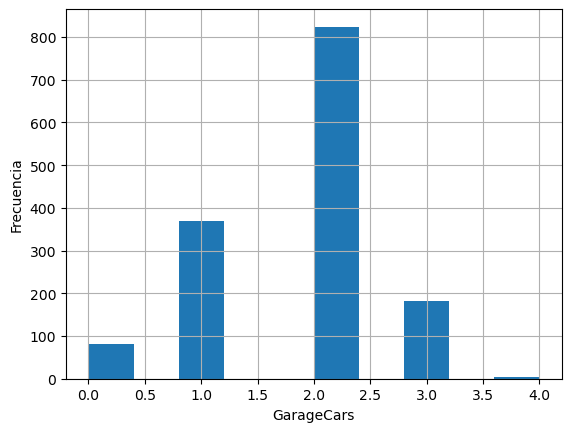

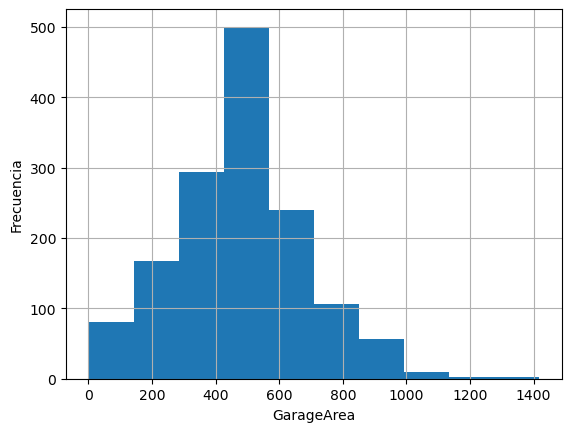

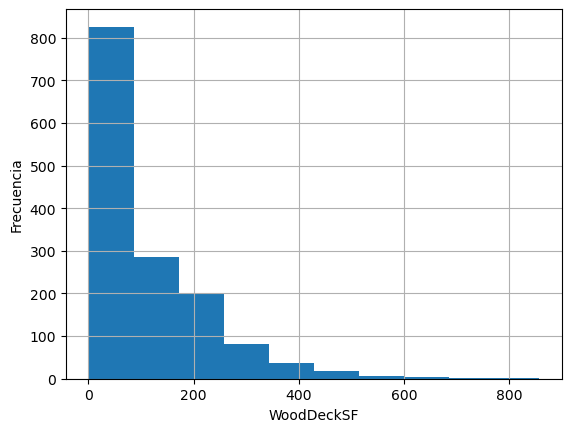

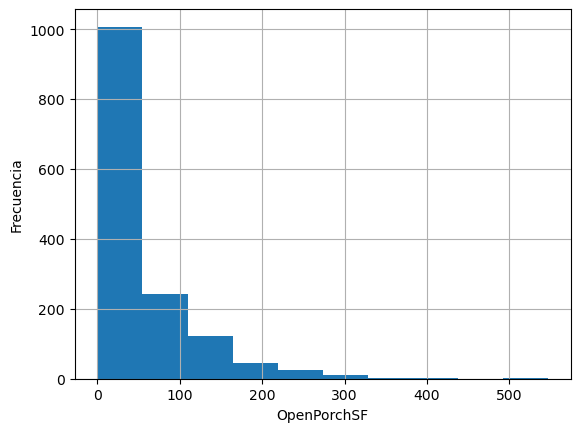

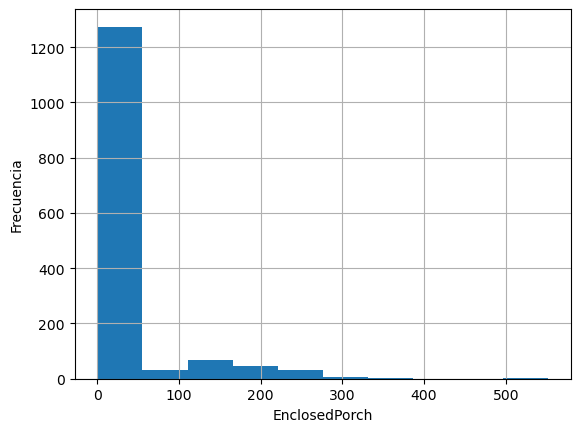

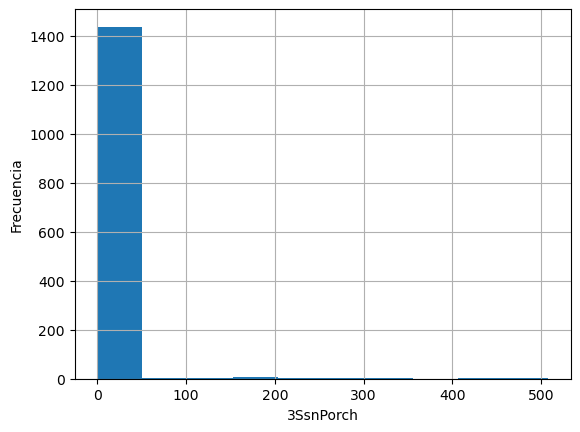

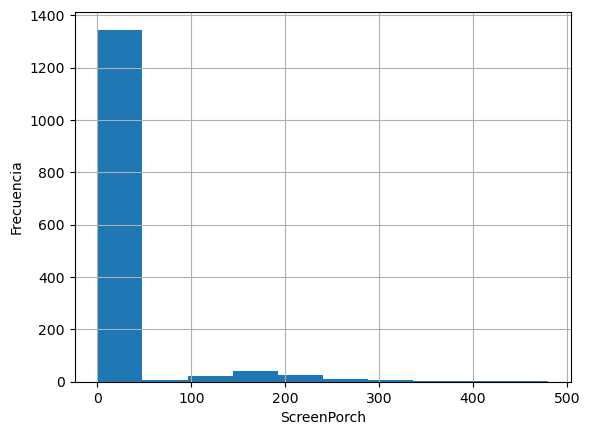

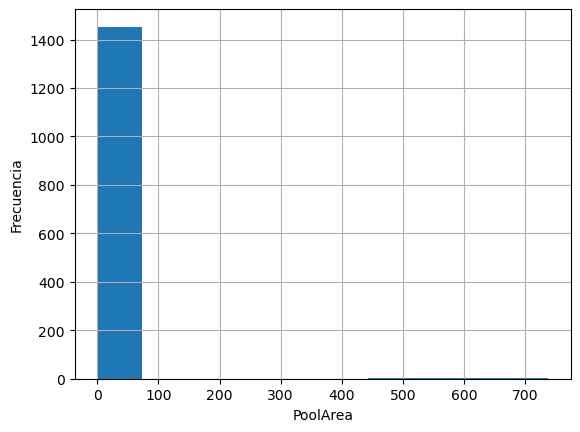

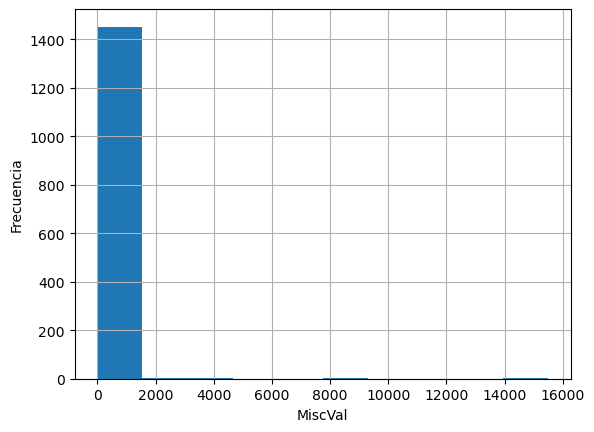

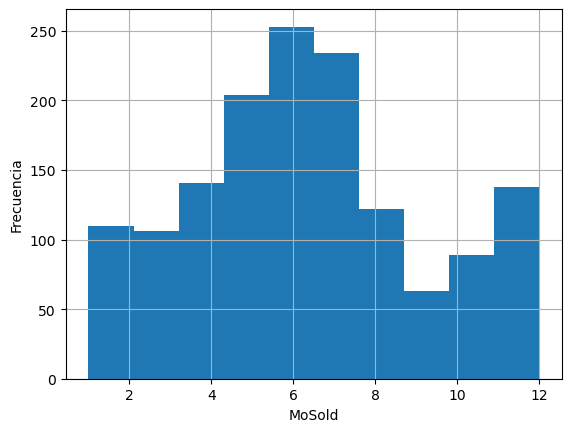

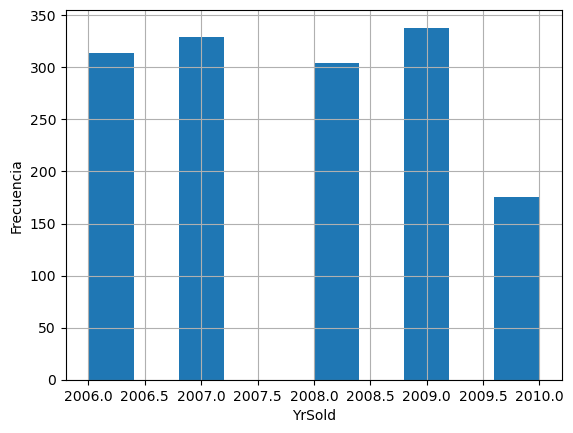

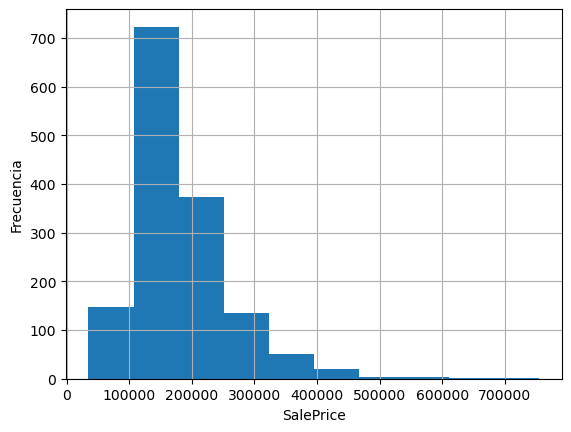

Se imprimieron los histogramas de 38 columnas


In [39]:
for col in train_df.select_dtypes(include='number').columns:
    plt.hist(train_df[col])
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()
print(f"Se imprimieron los histogramas de {len(train_df.select_dtypes(include='number').columns)} columnas")

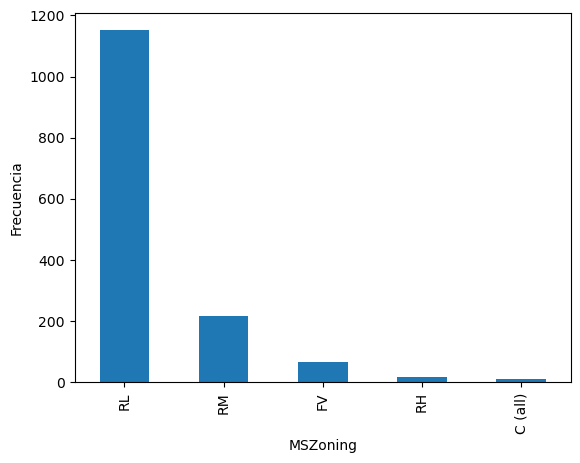

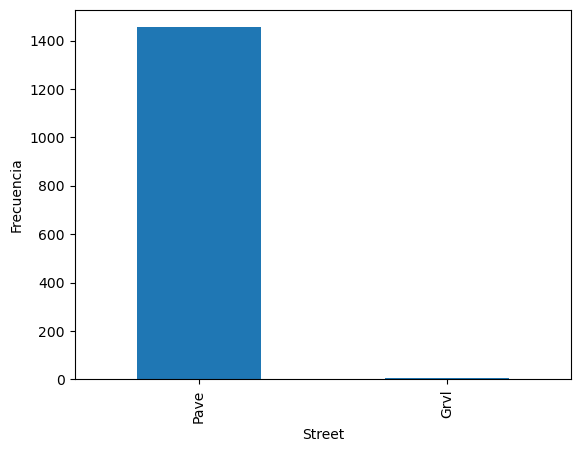

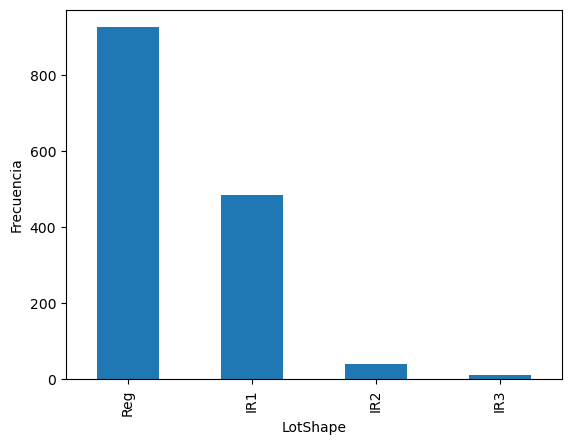

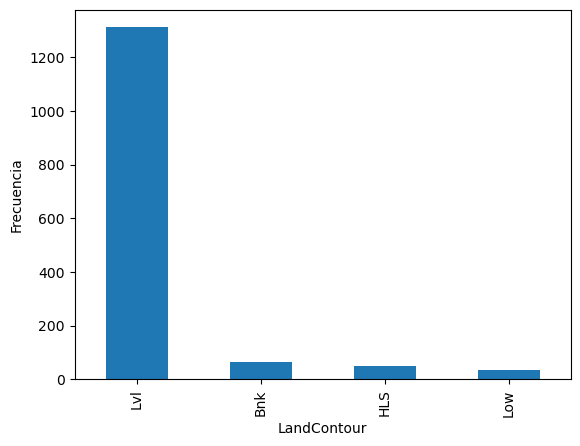

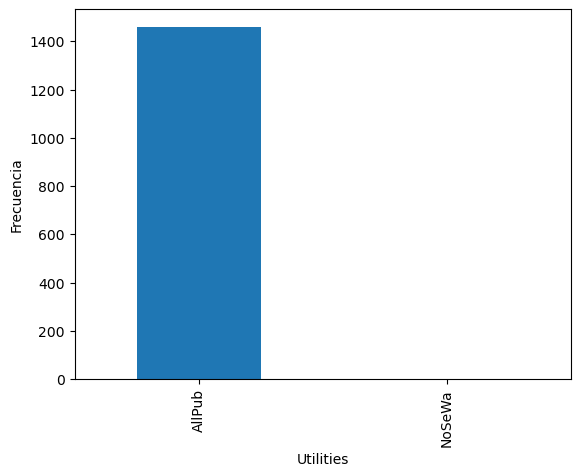

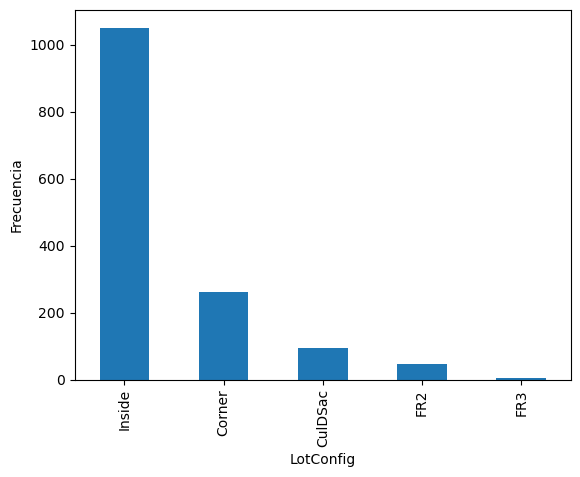

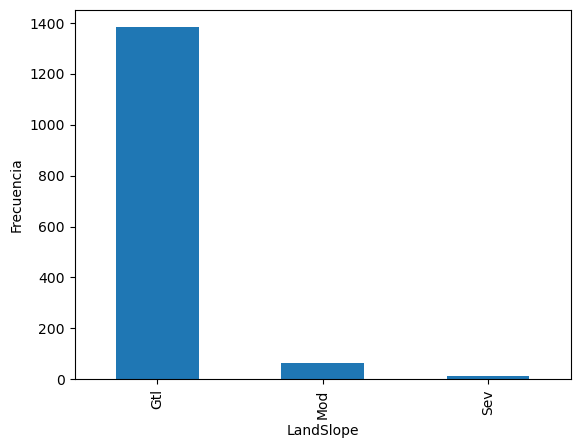

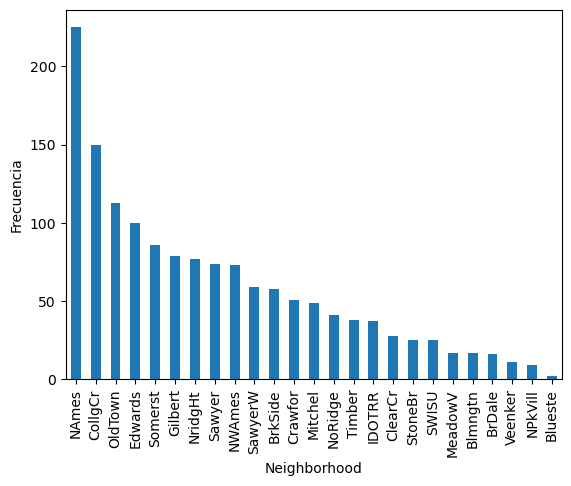

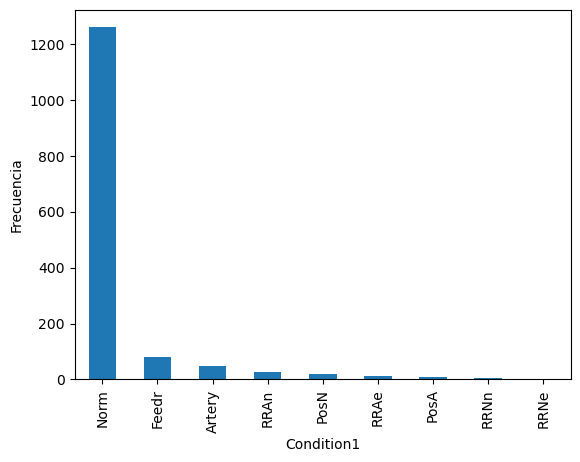

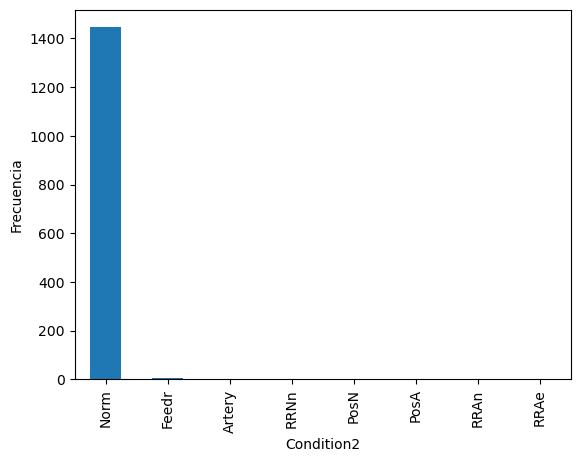

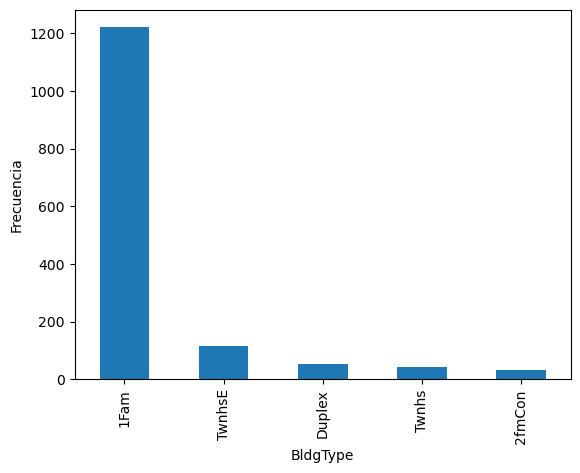

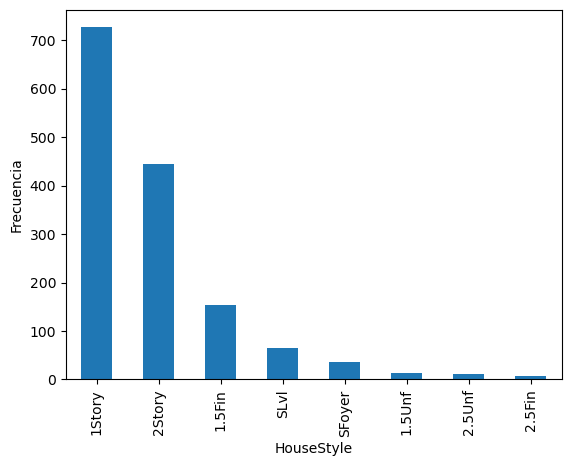

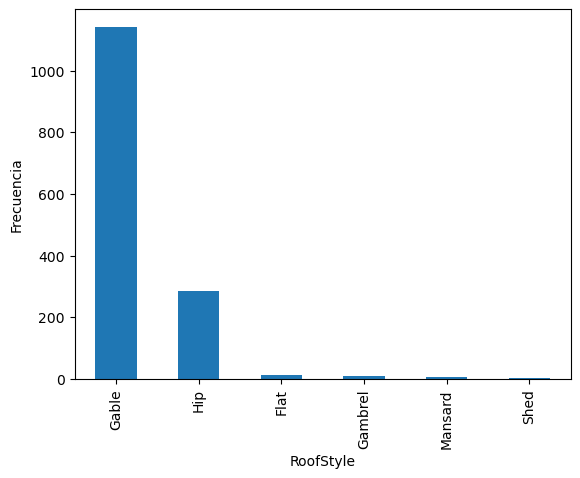

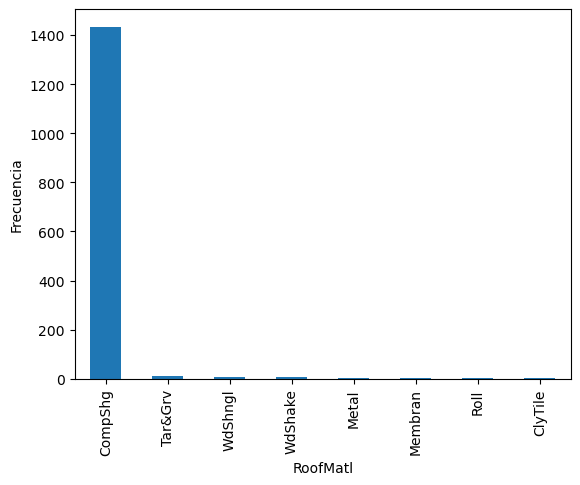

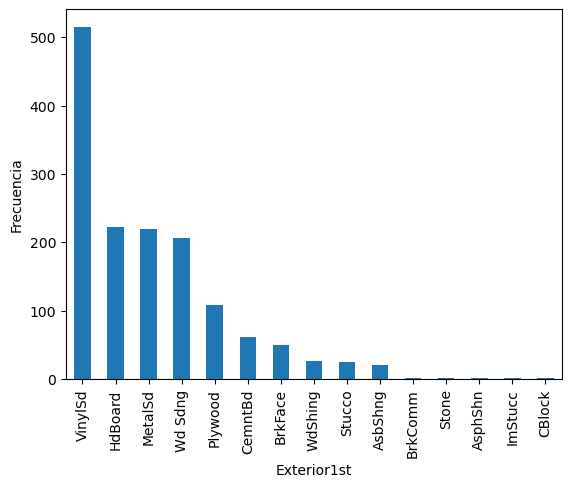

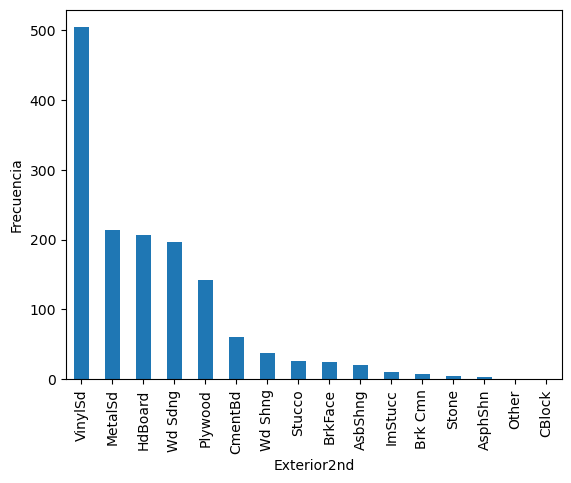

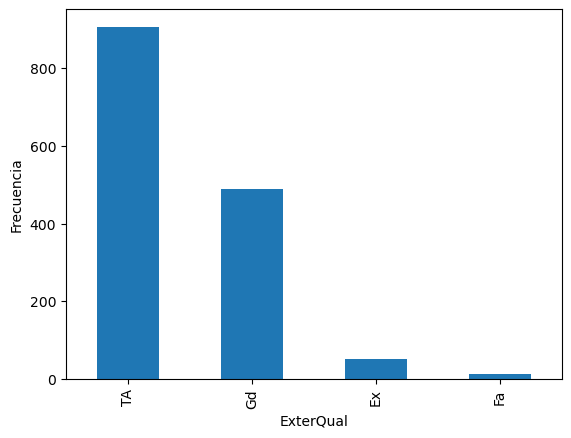

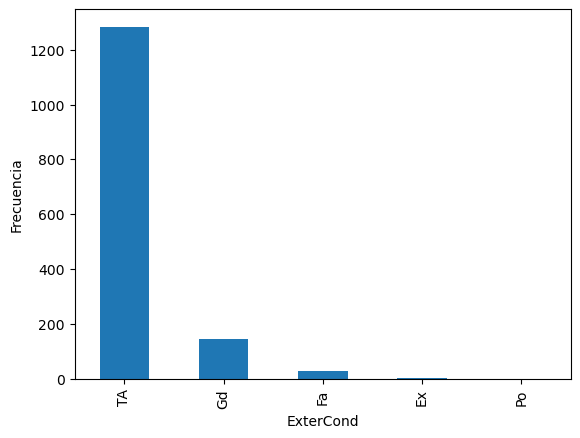

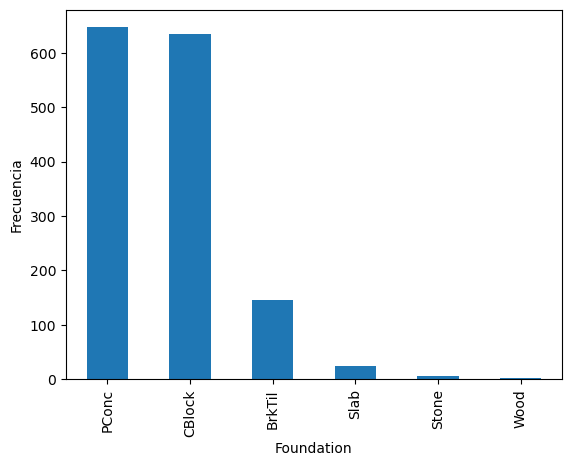

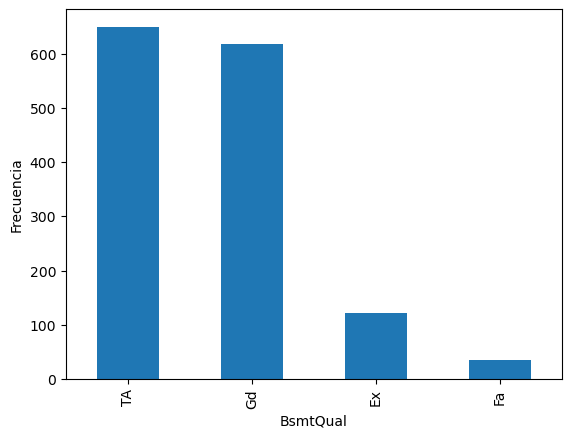

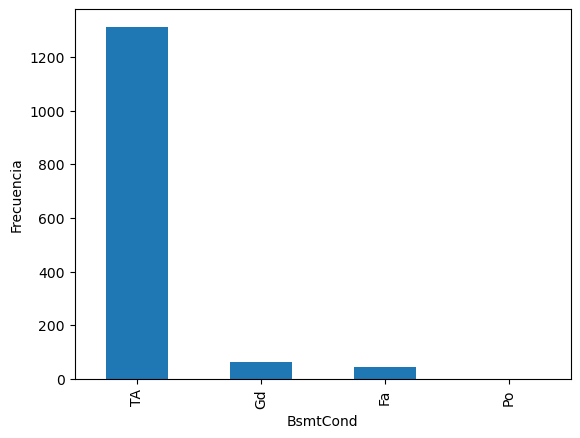

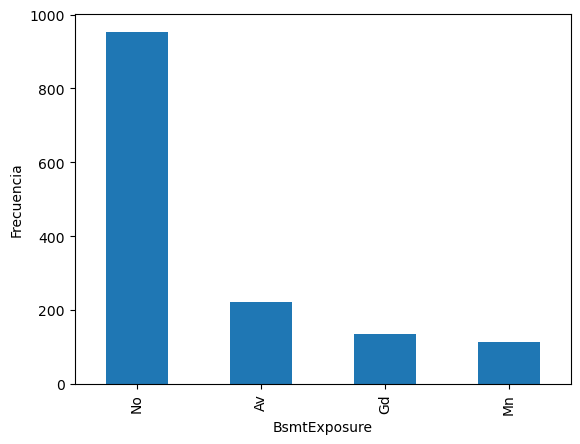

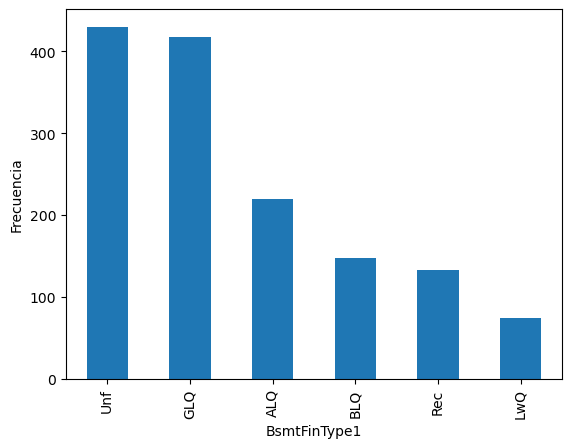

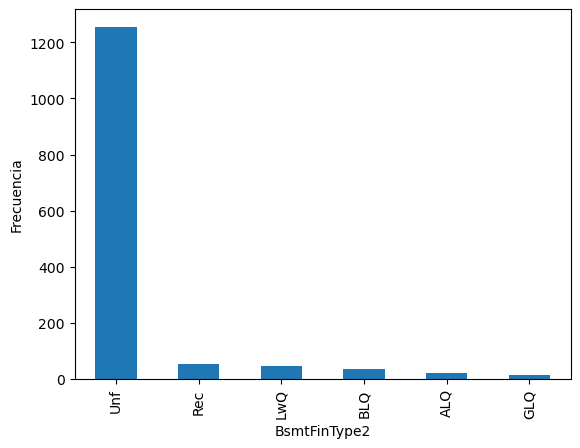

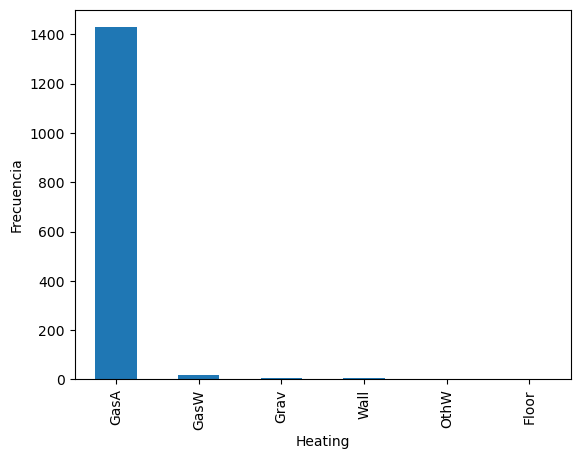

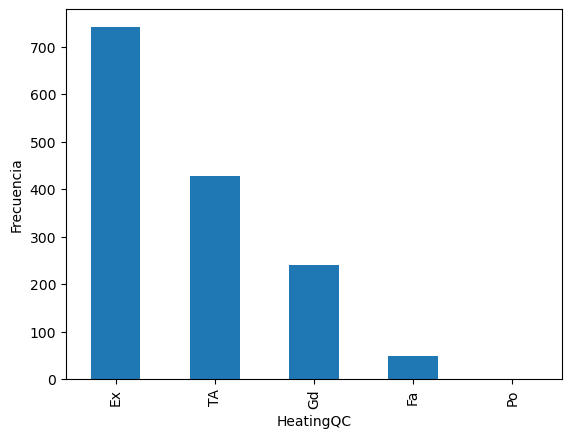

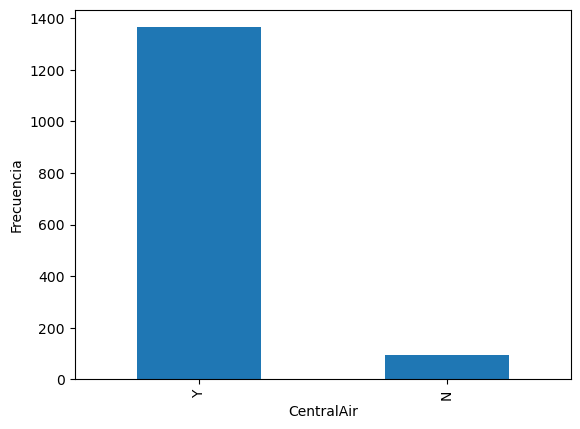

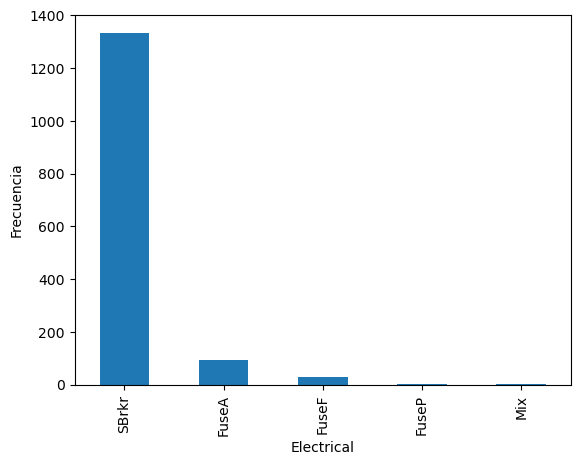

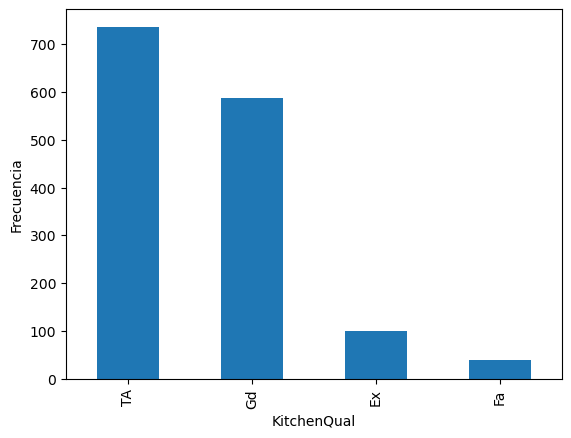

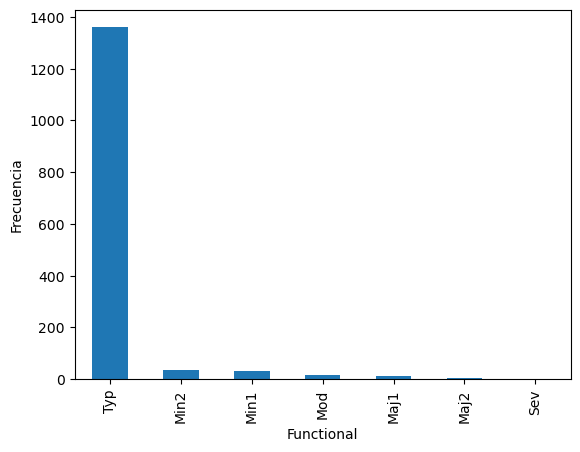

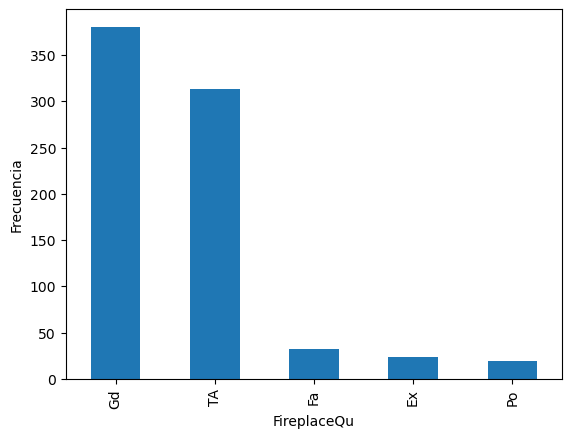

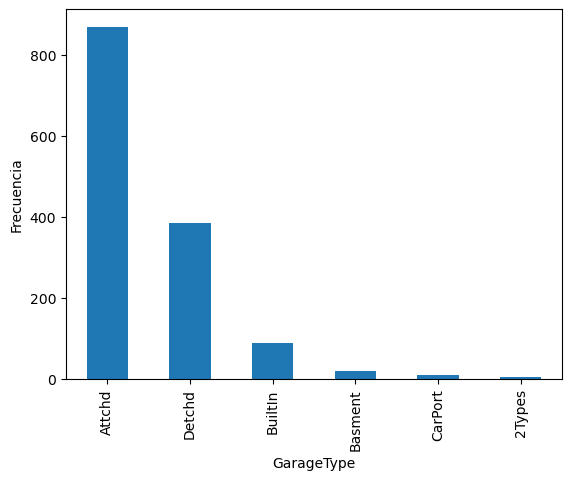

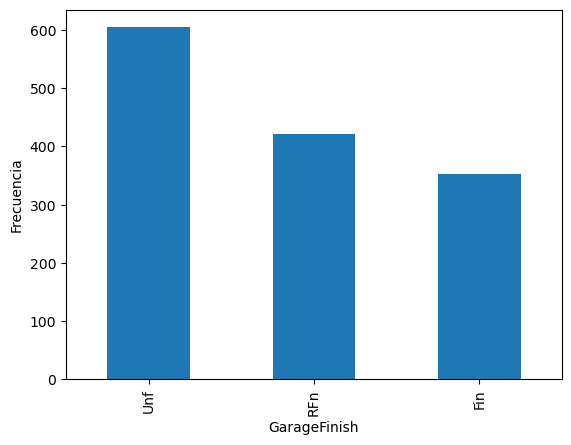

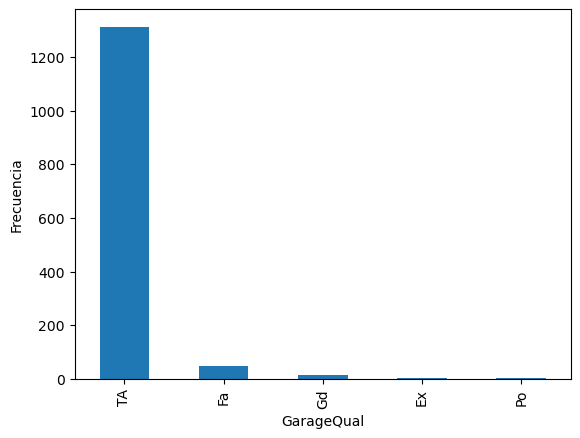

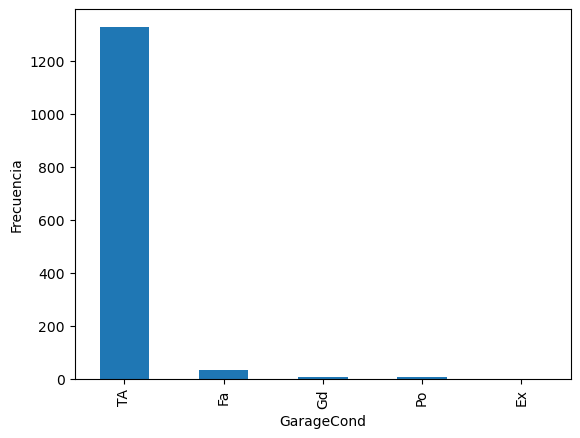

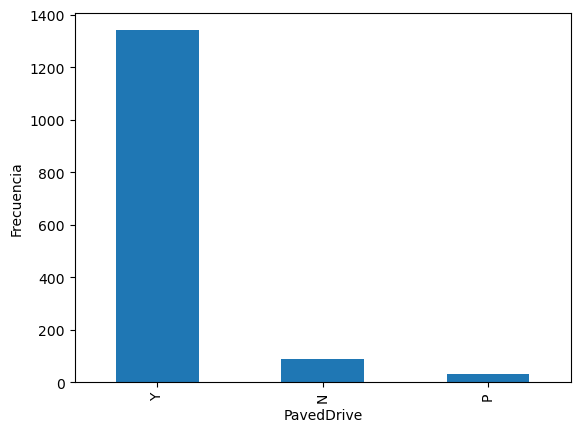

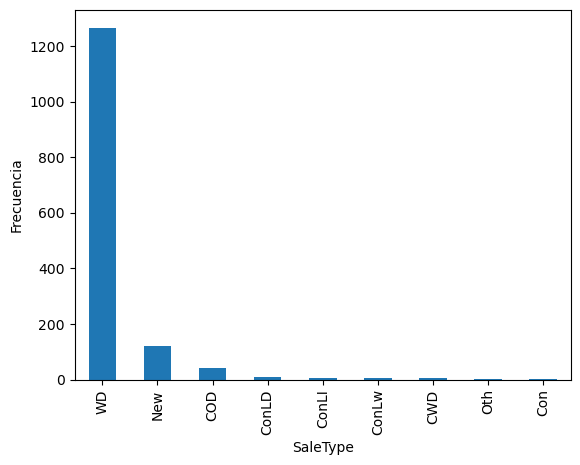

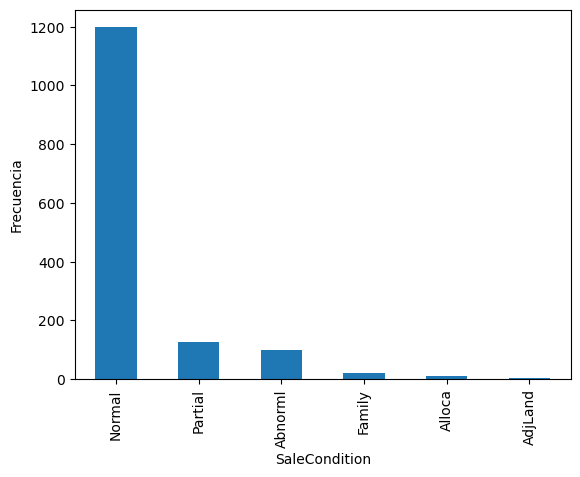

In [43]:
for col in train_df.select_dtypes(include='str').columns:
    train_df[col].value_counts().plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

Vamos a estratificar nuestros conjuntos de datos a partir de la variable numérica más correlacionada con la variable objetivo: OverallQual

In [40]:
train_df['OverallQual_cat'] = pd.cut(train_df['OverallQual'],
                                    bins=[0.,3.5,5.0,6.5,8.0,10.0],
                                    labels=[1,2,3,4,5])

train_df['OverallQual_cat'].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.show()

In [106]:
strat_train_df,strat_test_df = train_test_split(train_df,test_size=0.2,stratify=train_df['OverallQual_cat'],random_state=42)

In [116]:
def split_data(df, test_size):
    df['OverallQual_cat'] = pd.cut(df['OverallQual'],
                                    bins=[0.,3.5,5.0,6.5,8.0,10.0],
                                    labels=[1,2,3,4,5])
    strat_train_df,strat_test_df = train_test_split(train_df,test_size=0.2,stratify=train_df['OverallQual_cat'],random_state=42)
    return strat_train_df, strat_test_df

# Limpiar datos
## Vamos a manejar la eliminación de columnas con demasiada poca información así como la imputación de columnas numéricas y categoricas utilizando media/mediana y moda respectivamente

In [46]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

In [144]:
train_df, test_df = split_data(train_df,test_size=0.2)

X_train = train_df.drop('SalePrice',axis=1)
y_train = train_df['SalePrice'].copy()
X_test = test_df.drop('SalePrice',axis=1)
y_test = test_df['SalePrice'].copy()

In [135]:
num_cols = X_train.select_dtypes(include = 'number').columns 
cat_cols = X_train.select_dtypes(include = ['object','string']).columns

In [136]:
cat_cols = list(cat_cols)
num_cols = list(num_cols)

In [137]:
num_pipeline = make_pipeline(SimpleImputer(strategy='median'),StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(handle_unknown='ignore'))

preprocessing = ColumnTransformer([
    ('numerico',num_pipeline,num_cols),
    ('categorico',cat_pipeline,cat_cols)
])


In [84]:
train_df_prepared = preprocessing.fit_transform(train_df)
train_df_prepared.shape

(1460, 273)

In [85]:
train_df_prepared = pd.DataFrame(train_df_prepared.toarray(),columns=preprocessing.get_feature_names_out(),index = train_df.index)
train_df_prepared.head(5)

,numerico__Id,numerico__MSSubClass,numerico__LotFrontage,numerico__LotArea,numerico__OverallQual,numerico__OverallCond,numerico__YearBuilt,numerico__YearRemodAdd,numerico__MasVnrArea,numerico__BsmtFinSF1,...,categorico__SaleType_ConLw,categorico__SaleType_New,categorico__SaleType_Oth,categorico__SaleType_WD,categorico__SaleCondition_Abnorml,categorico__SaleCondition_AdjLand,categorico__SaleCondition_Alloca,categorico__SaleCondition_Family,categorico__SaleCondition_Normal,categorico__SaleCondition_Partial
0,-1.730865,0.073375,-0.220875,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.728492,-0.872563,0.460320,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.726120,0.073375,-0.084636,0.073480,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.723747,0.309859,-0.447940,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.721374,0.073375,0.641972,0.375148,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# Seleccionamos y entrenamos varios modelos para seleccionar el mejor
### Regresión lineal

In [146]:
from sklearn.linear_model import LinearRegression
lin_regresion = make_pipeline(preprocessing,LinearRegression())
lin_regresion.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerico', ...), ('categorico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [147]:
lin_predicciones = lin_regresion.predict(X_test)

In [149]:
lin_predicciones[:5].round(-2)

array([118200., 182200., 230200., 467900., 140400.])

In [150]:
y_test[:5]

500     113000
699     196000
907     250000
769     538000
1129    140000
Name: SalePrice, dtype: int64

In [152]:
def root_mean_squared_error(y_test,y_label):
    mse = mean_squared_error(y_test,y_label)
    rmse = np.sqrt(mse)
    return rmse

In [155]:
from sklearn.metrics import mean_squared_error
lin_rmse = root_mean_squared_error(y_test,lin_predicciones)
lin_rmse.round(0)

np.float64(31628.0)

### Random Forest Regressor

In [159]:
from sklearn.model_selection import cross_val_score

In [157]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,RandomForestRegressor(random_state=42))
forest_reg.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerico', ...), ('categorico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [160]:
forest_rmse = -cross_val_score(forest_reg,X_train,y_train,scoring='neg_root_mean_squared_error',cv=10)
forest_rmse

array([27976.00472896, 35235.99755891, 24947.5683368 , 26781.12622985,
       28592.70697736, 26472.11952785, 25956.21381668, 22438.30316821,
       22760.5005783 , 24902.36714486])

In [162]:
pd.Series(forest_rmse).describe()

count       10.000000
mean     26606.290807
std       3629.844089
min      22438.303168
25%      24913.667443
50%      26214.166672
75%      27677.285104
max      35235.997559
dtype: float64

### SVM

In [161]:
from sklearn.svm import SVR

svr_reg = make_pipeline(preprocessing,SVR())
svr_reg.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerico', ...), ('categorico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [163]:
svr_rmse = -cross_val_score(forest_reg,X_train,y_train,scoring='neg_root_mean_squared_error',cv=3)
pd.Series(svr_rmse).describe()

count        3.000000
mean     29373.700695
std       5670.646692
min      24512.215372
25%      26258.941026
50%      28005.666679
75%      31804.443357
max      35603.220034
dtype: float64

El modelo que tuvo mejor desempeño fue el Random Forest Regressor, por lo que vamos a hacer las predicciones de la competición utilizando este modelo

In [170]:
predicciones_finales = forest_reg.predict(test_df)

In [173]:
df_predicciones = pd.Series(predicciones_finales)

In [178]:
df_predicciones.to_csv('predicciones.csv',index=False)

In [181]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predicciones_finales
})

In [183]:
submission.to_csv('submission.csv',index=False)